# 🫀Heart Disease Prediction

## Exploratory Data Analysis (EDA)

In this notebook, we explore the dataset using statistical summaries and visualizations to better understand feature distributions, relationships, and potential data quality issues before preprocessing and model development.

`Note`: *The plots are based on the raw dataset. Therefore, zero-coded values in 
Cholesterol and RestingBP, as well as negative Oldpeak values, may affect the 
observed distributions. These issues are intentionally not corrected in this notebook.*


In [1]:
# Import the tools we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

%matplotlib inline

In [2]:
# project path
project_root = Path.cwd().parent
data_dir = project_root / "data"
raw_data_dir = data_dir / "raw"

data_file = raw_data_dir / "heart.csv"

In [3]:
# Load Dataset
df = pd.read_csv(data_file)
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


### 1.What is the number of infected and uninfected people?

Text(0, 0.5, 'Count')

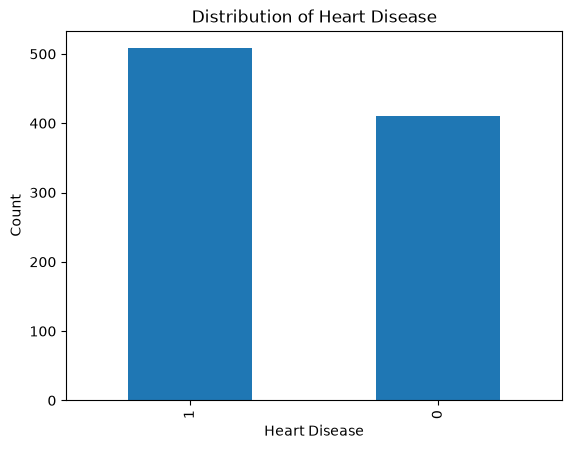

In [4]:
df["HeartDisease"].value_counts().plot(kind='bar')
plt.title("Distribution of Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Count")

#### 1.What do we observe?
The dataset contains 508 patients with heart disease and 410 without heart disease. The target classes are relatively balanced, although patients with heart disease are slightly more frequent.

#### 2.Why does it matter?
Since the target classes are only slightly imbalanced, severe class imbalance techniques such as SMOTE are not immediately required. However, stratified sampling should be used when splitting the dataset, and evaluation metrics beyond accuracy should still be reported.

### 2.How is the age of people distributed in the dataset?

Text(0.5, 0.98, 'Age Distribution')

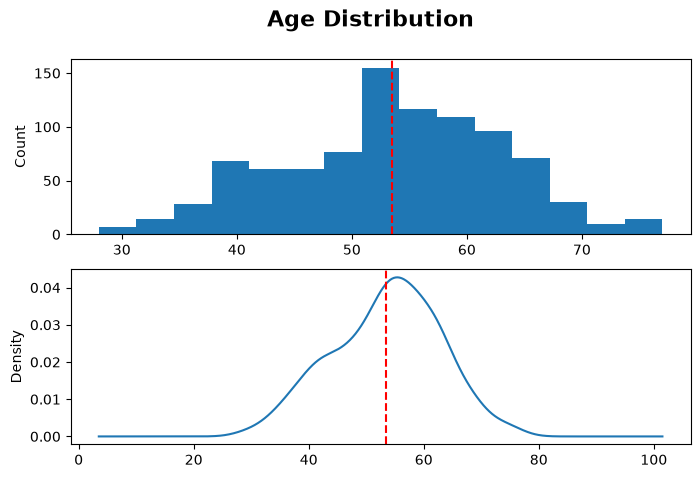

In [5]:
fig,(ax1, ax2) = plt.subplots(nrows=2,
                              ncols=1,
                              figsize=(8, 5),)


ax1.hist(df["Age"], bins=15)
ax1.axvline(df["Age"].mean(), color='red', linestyle= "--")
ax1.set_ylabel("Count")

ax2 = df["Age"].plot(kind="density")
ax2.axvline(df["Age"].mean(), color='red', linestyle= "--")
ax2.set(ylabel=" ")
ax2.set_ylabel("Density")
fig.suptitle("Age Distribution",fontsize = 16 ,fontweight = "bold")

### 2.1 Is there an outlier in the Age column?
#### 2.2 Is there a dot (○) outside the two end lines of the box?

C:\Users\www.markazi.co\AppData\Local\Temp\ipykernel_3700\4118313545.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(df["Age"], vert=False)


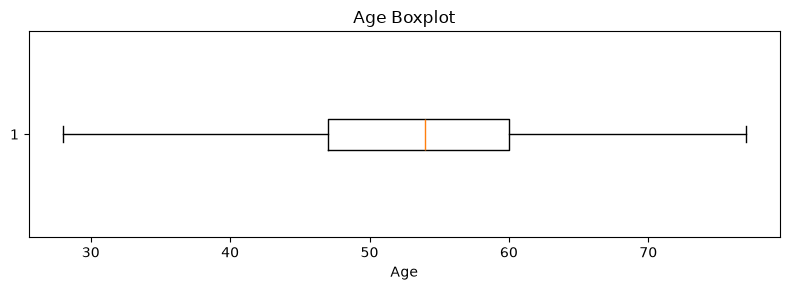

In [6]:
fig, ax = plt.subplots(figsize=(8, 3))

ax.boxplot(df["Age"], vert=False)

ax.set_title("Age Boxplot")
ax.set_xlabel("Age")

plt.tight_layout()
plt.show()

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 97.6 KB


In [8]:
numeric_features = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]

missing_columns = set(numeric_features) - set(df.columns)
assert not missing_columns, f"Missing columns: {missing_columns}"
   

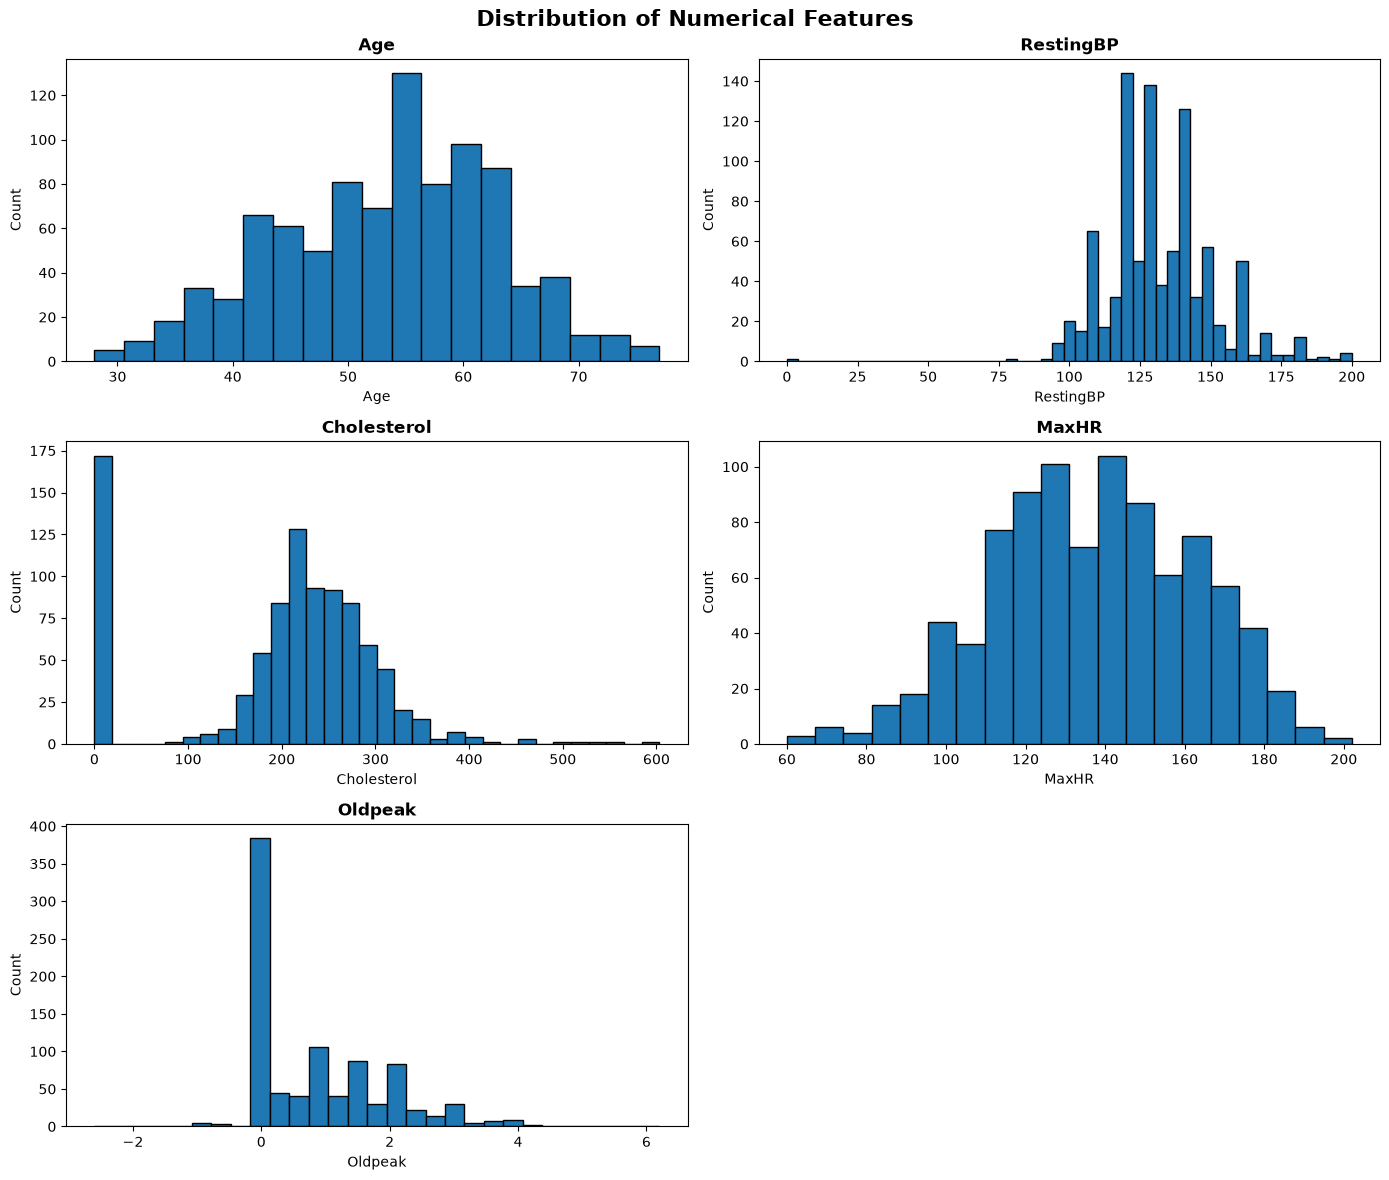

In [9]:
# Numerical features
numerical_features = [
    "Age",
    "RestingBP",
    "Cholesterol",
    "MaxHR",
    "Oldpeak"
]

# Create subplots
fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(14, 12)
)

# Convert axes to a 1D array
axes = axes.flatten()

# Plot histograms
for ax, feature in zip(axes, numerical_features):

    ax.hist(
        df[feature],
        bins="auto",
        edgecolor="black"
    )

    ax.set_title(feature, fontsize=12, fontweight="bold")
    ax.set_xlabel(feature)
    ax.set_ylabel("Count")

# Remove the unused subplot
fig.delaxes(axes[-1])

fig.suptitle(
    "Distribution of Numerical Features",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

## Feature vs Target Analysis
### 1.Does the age of people with heart disease differ from that of healthy people?

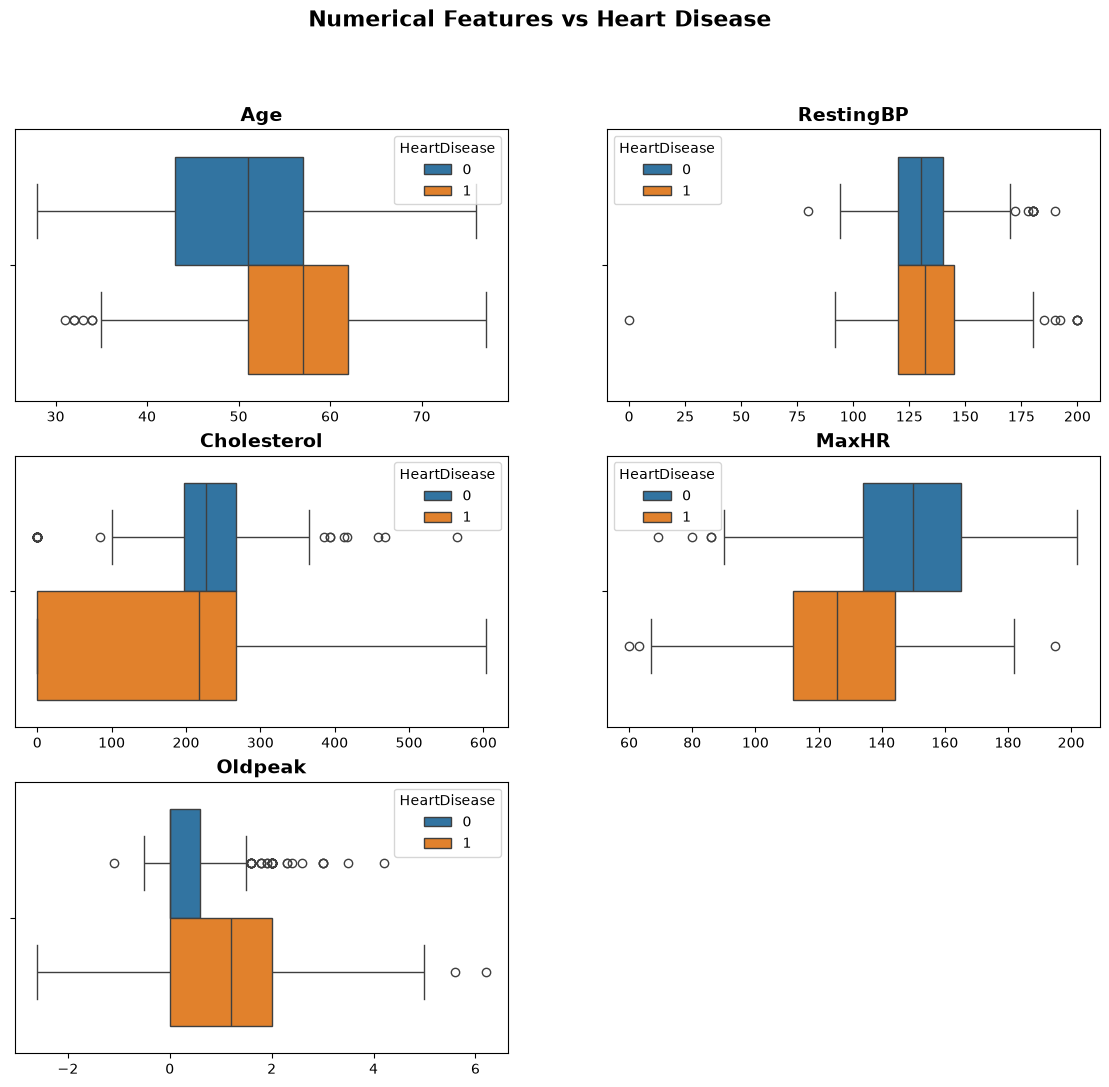

In [10]:
# Numerical features
numerical_features = [
    "Age",
    "RestingBP",
    "Cholesterol",
    "MaxHR",
    "Oldpeak"
]

fig, axes = plt.subplots(figsize=(14, 12),
                          nrows=3,
                          ncols=2)

fig.suptitle("Numerical Features vs Heart Disease",
              fontsize=16,
              fontweight="bold")
# create axes
axes = axes.flatten()

# create a loops
for ax, feature in zip(axes,numerical_features):
    sns.boxplot(data=df,
                  x=feature,
                  hue="HeartDisease",
                  ax=ax)
    ax.set_title(feature, fontsize=14, fontweight="bold")
    ax.set(xlabel=None)
fig.delaxes(axes[-1])

# Key Observations📌 
### Observation 1.Age

Observation

Patients with heart disease tend to be older than healthy individuals.
The median age of the heart disease group is noticeably higher than that of the healthy group.

Interpretation

Age appears to be positively associated with heart disease, suggesting that older individuals in this dataset are more likely to have the disease.

### Observation 2.RestingBP

Observation

The distributions of resting blood pressure for the two groups overlap substantially.
Both groups have similar median values and a comparable spread.

Interpretation

RestingBP does not appear to clearly distinguish healthy individuals from patients with heart disease.

#### note📌

`The RestingBP feature included 1 zero-valued number, which may have influenced it and should be considered when interpreting this result.`

### Observation 3.Cholesterol

Observation

The cholesterol distributions of the two groups are highly similar.
Several outliers are present in both groups.

Interpretation

Based on this dataset, cholesterol alone does not show a strong relationship with heart disease.

#### note📌

`The Cholesterol feature originally contained a large number of zero values, which may influence its distribution and should be considered when interpreting this result.`

### Observation 4.MaxHR

Observation

Patients with heart disease generally exhibit lower maximum heart rates.
The median MaxHR is noticeably lower in the heart disease group.

Interpretation

MaxHR appears to be negatively associated with heart disease and may serve as a useful predictive feature.

### Observation 5.Oldpeak

Observation

Patients with heart disease tend to have higher Oldpeak values.
The healthy group is concentrated around lower Oldpeak values.

Interpretation

Oldpeak shows a clear separation between the two groups, suggesting that it is an informative feature for predicting heart disease.

## Overall Conclusion📌 
### Conclusion

Among the numerical features, **Age**, **MaxHR**, and **Oldpeak** exhibit noticeable differences between healthy individuals and patients with heart disease, indicating that these variables may have strong predictive value.

In contrast, **RestingBP** and **Cholesterol** show considerable overlap between the two groups, suggesting a weaker relationship with the target variable in this dataset.

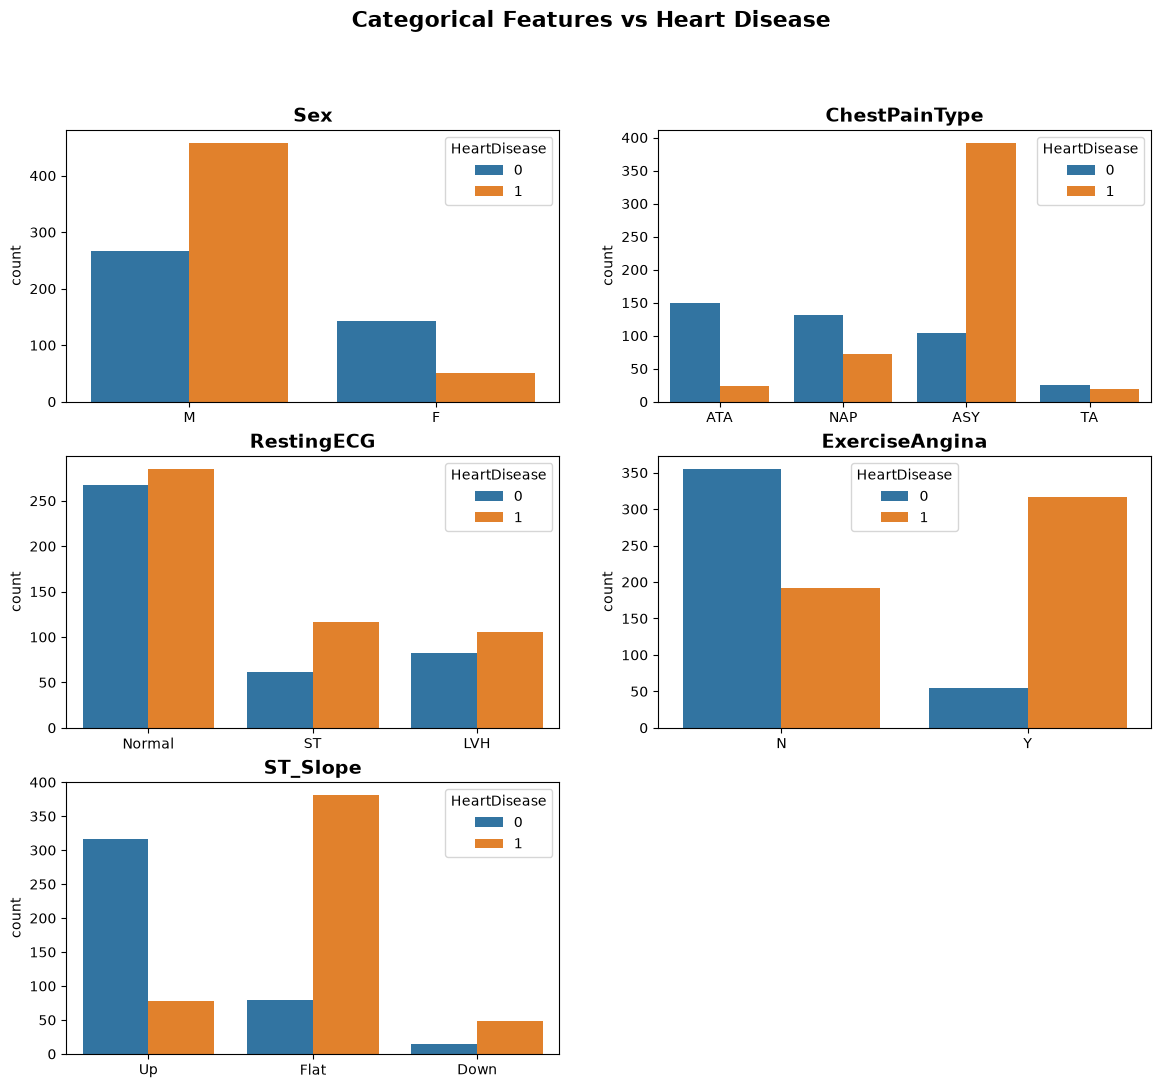

In [11]:
# Categorical features
categorical_features = [
    "Sex",
    "ChestPainType",
    "RestingECG",
    "ExerciseAngina",
    "ST_Slope"
]

fig, axes = plt.subplots(figsize=(14, 12),
                          nrows=3,
                          ncols=2)

fig.suptitle("Categorical Features vs Heart Disease",
              fontsize=16,
              fontweight="bold")
# create axes
axes = axes.flatten()

# create a loops
for ax, feature in zip(axes,categorical_features):
    sns.countplot(data=df,
                  x=feature,
                  hue="HeartDisease",
                  ax=ax)
    ax.set_title(feature, fontsize=14, fontweight="bold")
    ax.set(xlabel=None)
fig.delaxes(axes[-1])

# Categorical Features vs Heart Disease📌
### Observation 1: Sex

✅ Observation

The dataset contains substantially more male patients than female patients.
Among male patients, the number of individuals diagnosed with heart disease is considerably higher than those without heart disease.
In contrast, female patients are more frequently classified as healthy.

Interpretation

Sex appears to be associated with the target variable. Male patients in this dataset exhibit a higher prevalence of heart disease than female patients.

### Observation 2: ChestPainType

✅ Observation

Patients with ASY (Asymptomatic) chest pain account for the largest proportion of heart disease cases.
Patients with ATA are predominantly healthy.
The NAP category shows a more balanced distribution.

Interpretation

Chest pain type appears to be a highly informative feature, particularly the ASY category, which is strongly associated with heart disease.

### Observation 3: RestingECG

✅ Observation

The Normal ECG category contains both healthy and diseased individuals in comparable numbers.
The ST category includes noticeably more patients with heart disease than healthy individuals.
The LVH category shows only a modest difference between the two groups.

Interpretation

Resting ECG may provide useful information for prediction, although its discriminative ability appears weaker than ChestPainType or ST_Slope.

### Observation 4: ExerciseAngina

✅ Observation

Most patients without exercise-induced angina (N) are healthy.
Patients with exercise-induced angina (Y) are predominantly diagnosed with heart disease.

Interpretation

Exercise-induced angina shows a strong relationship with heart disease and is likely to be an important predictive feature.

### Observation 5: ST_Slope

✅ Observation

Patients with an Up ST slope are mostly healthy.
Patients with a Flat ST slope are predominantly diagnosed with heart disease.
The Down category contains relatively few observations but also shows a higher proportion of heart disease.

Interpretation

ST_Slope demonstrates one of the strongest associations with the target variable and is expected to be among the most influential predictors.

## Overall Conclusion📌 
### Conclusion

The categorical feature analysis reveals that several variables exhibit clear associations with heart disease.

Among them, **ChestPainType**, **ExerciseAngina**, and **ST_Slope** show the strongest separation between healthy and diseased individuals, suggesting that these variables are likely to be highly informative predictors.

In contrast, **RestingECG** displays a weaker relationship with the target variable.

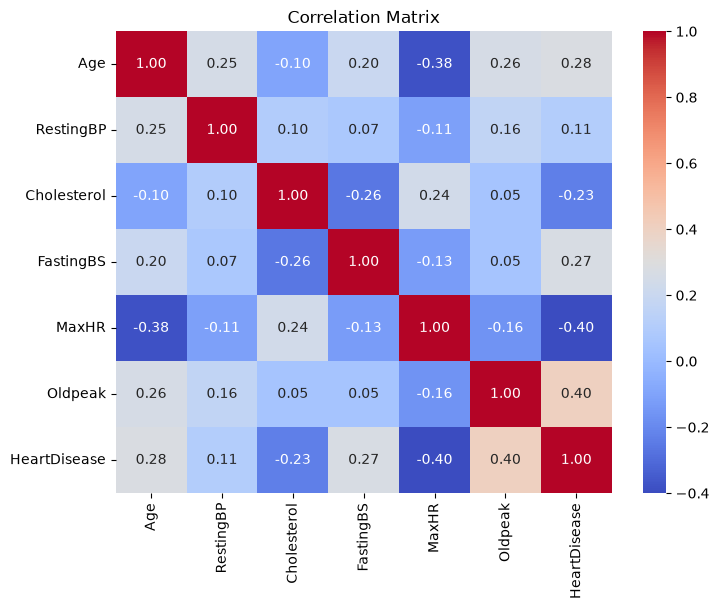

In [12]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

# Heapmap Result

### Observation 1
✅ Oldpeak shows the strongest positive correlation with HeartDisease (r ≈ 0.40).

### Observation 2
✅ MaxHR has the strongest negative correlation with HeartDisease (r ≈ -0.40).

### Observation 3
✅ Age (0.28) و FastingBS (0.27)They also have a positive but weak to moderate correlation with heart disease.

### Observation 4
✅ RestingBP Almost no significant linear association with heart disease.

### Observation 5
✅ Cholesterol It has a weak and even negative correlation (-0.23) with the target.
`The weak correlation of Cholesterol with the target may be influenced by the large number of invalid zero values observed during the data quality assessment.`


# EDA Summary

The exploratory data analysis provided several important insights into the heart disease dataset:

- The dataset contains **918 observations** with **12 features** and does not include any missing values.
- Data quality assessment identified invalid values in the **Cholesterol**, **RestingBP**, and **Oldpeak** features, which will require preprocessing before model training.
- The target variable is only **slightly imbalanced** (508 patients with heart disease and 410 without), indicating that severe class imbalance is not a major concern.
- Among the categorical features, **ChestPainType**, **ExerciseAngina**, and **ST_Slope** showed the strongest association with heart disease.
- Among the numerical features, **Age**, **MaxHR**, and **Oldpeak** demonstrated noticeable differences between healthy and diseased individuals.
- The correlation analysis confirmed that **Oldpeak** and **MaxHR** have the strongest linear relationships with the target variable, while **Cholesterol** and **RestingBP** showed relatively weak correlations.
- Overall, several features appear to have meaningful predictive potential and will be further prepared during the preprocessing stage before training machine learning models.